In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [19]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    number3: int
    number4: int
    operation2: str
    finalNumber: int
    finalNumber2: int


def decide_node(state: AgentState) -> str:
    if state["operation"] == "+":
        return "add_node1"
    elif state["operation"] == "-":
        return "sub_node1"


def decide_node2(state: AgentState) -> str:
    if state["operation2"] == "+":
        return "add_node2"
    elif state["operation2"] == "-":
        return "sub_node2"


def add(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] + state["number2"]
    return state


def sub(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def add2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state


def sub2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state


graph = StateGraph(AgentState)

graph.add_node("route", lambda state: state)
graph.add_node("route2", lambda state: state)

graph.add_node("add_node1", add)
graph.add_node("add_node2", add2)
graph.add_node("sub_node1", sub)
graph.add_node("sub_node2", sub2)

graph.add_edge(START, "route")
graph.add_conditional_edges(
    "route", decide_node, {"add_node1": "add_node1", "sub_node1": "sub_node1"}
)
graph.add_edge("add_node1", "route2")
graph.add_edge("sub_node1", "route2")

graph.add_conditional_edges(
    "route2", decide_node2, {"add_node2": "add_node2", "sub_node2": "sub_node2"}
)
graph.add_edge("add_node2", END)
graph.add_edge("sub_node2", END)

app = graph.compile()

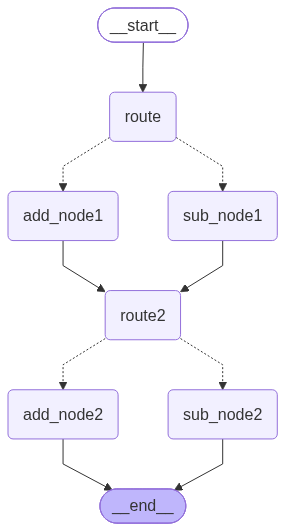

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
initial_state = AgentState(
    number1=10, number2=5, operation="-", number3=7, number4=2, operation2="+"
)
final_state = app.invoke(initial_state)
print(final_state)

{'number1': 10, 'number2': 5, 'operation': '-', 'number3': 7, 'number4': 2, 'operation2': '+', 'finalNumber': 5, 'finalNumber2': 9}
